# 03. Thí nghiệm với các phương pháp bậc một

Khảo sát tham số cho gradient descent, SGD và accelerated gradient descent.
Mỗi nhóm so sánh sinh ra hai hình: theo số vòng lặp và theo thời gian chạy.

Notebook này đọc bài toán đã cố định từ `data/processed/`, không xây lại dữ liệu.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.plotting import set_style

set_style()


In [2]:
from src.data import load_problem
from src.plotting import (
    plot_comparison,
    plot_theoretical_rate,
    styles_from_keys,
    summary_table,
    observed_rate,
)
from src.runner import (
    agd_grid,
    best_result,
    gd_backtracking_grid,
    gd_fixed_step_grid,
    run_or_load,
    sgd_batch_size_grid,
    sgd_schedule_grid,
)

problem, config = load_problem()
print(f"n = {problem.n}, d = {problem.d}, lambda = {problem.lam:.6g}")
print(f"L = {problem.L:.6g}, mu = {problem.mu:.6g}, kappa = {problem.kappa:.6g}")
print(f"f* = {problem.f_star:.10g}")

n = 160000, d = 280, lambda = 0.01
L = 2.68309, mu = 0.01, kappa = 268.309


f* = 0.02374302921


## A. Gradient descent với độ dài bước cố định

Lưới bao gồm cả `t = 2.1/L`, nằm ngoài ngưỡng ổn định `2/L`, để quan sát hiện
tượng phân kỳ.

[1/8] GD ($t = 2.1/L$)                              status=diverged   gap=5.357e+11 time=5.2806s


[2/8] GD ($t = 2/L$)                                status=stalled    gap=4.878e-08 time=4.9897s


[3/8] GD ($t = 1.9/L$)                              status=converged  gap=0.000e+00 time=6.0440s


[4/8] GD ($t = 1/L$)                                status=stalled    gap=0.000e+00 time=10.1645s


[5/8] GD ($t = 0.5/L$)                              status=stalled    gap=4.510e-17 time=17.0313s


[6/8] GD ($t = 0.1/L$)                              status=max_iter   gap=8.166e-12 time=33.5697s


[7/8] GD ($t = 0.01/L$)                             status=max_iter   gap=3.691e-04 time=34.8830s


[8/8] GD ($t = 2/(L+\mu)$)                          status=max_iter   gap=8.292e-16 time=40.0624s
[done] gd_fixed: 8 runs written to gd_fixed.json


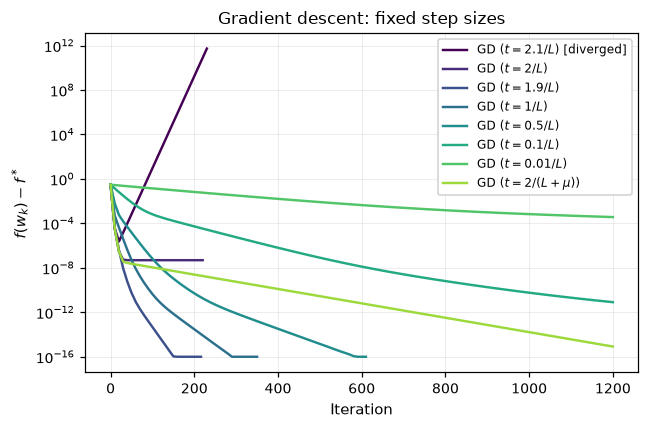

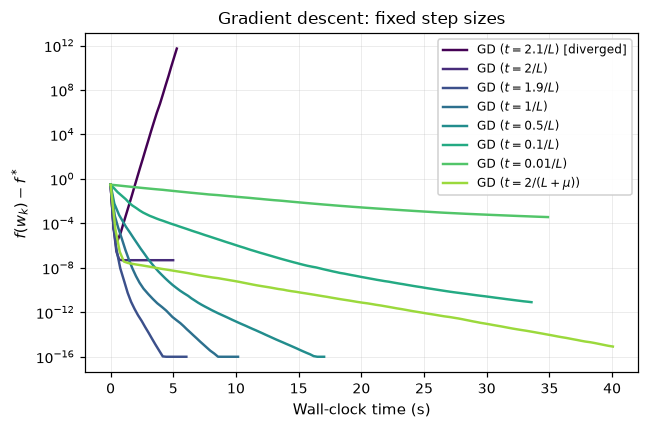

In [3]:
gd_fixed = run_or_load(problem, "gd_fixed", gd_fixed_step_grid(problem), repeats=3, extra=config)

plot_comparison(
    gd_fixed,
    problem.f_star,
    stem="gd_fixed",
    title="Gradient descent: fixed step sizes",
)
plt.show()

In [4]:
summary_table(gd_fixed, problem.f_star)

,method,setup,status,iters_to_1e-06,time_to_1e-06_s,final_f,final_gap,final_grad_norm,total_time_s,n_f_evals,n_grad_evals,n_sample_grads
0,gradient_descent,GD ($t = 2.1/L$),diverged,NaN,NaN,5.356748e+11,5.356748e+11,1.695442e+06,5.280552,231,231,36960000
1,gradient_descent,GD ($t = 2/L$),stalled,20.0,0.464670,2.374308e-02,4.878272e-08,5.116410e-04,4.989693,221,221,35360000
2,gradient_descent,GD ($t = 1.9/L$),converged,20.0,0.478354,2.374303e-02,0.000000e+00,7.598943e-11,6.044013,217,217,34720000
3,gradient_descent,GD ($t = 1/L$),stalled,40.0,1.180695,2.374303e-02,0.000000e+00,6.179336e-10,10.164512,351,351,56160000
4,gradient_descent,GD ($t = 0.5/L$),stalled,80.0,2.401746,2.374303e-02,4.510281e-17,2.758771e-09,17.031322,611,611,97760000
5,gradient_descent,GD ($t = 0.1/L$),max_iter,380.0,10.128989,2.374303e-02,8.166141e-12,1.378358e-06,33.569690,1201,1201,192160000
6,gradient_descent,GD ($t = 0.01/L$),max_iter,NaN,NaN,2.411210e-02,3.690684e-04,1.652955e-02,34.883011,1201,1201,192160000
7,gradient_descent,GD ($t = 2/(L+\mu)$),max_iter,20.0,0.728531,2.374303e-02,8.291978e-16,6.671406e-08,40.062394,1201,1201,192160000


Kết luận cần viết ra: khoảng độ dài bước dùng được, giá trị tốt nhất quan sát
được, và điều gì xảy ra khi vượt ngưỡng `2/L`.

## B. Gradient descent với backtracking

[1/9] GD bt ($\alpha = 0.1$, $\beta = 0.5$)         status=stalled    gap=-3.469e-18 time=7.7021s


[2/9] GD bt ($\alpha = 0.1$, $\beta = 0.8$)         status=stalled    gap=0.000e+00 time=9.5225s


[3/9] GD bt ($\alpha = 0.1$, $\beta = 0.9$)         status=stalled    gap=0.000e+00 time=10.8031s


[4/9] GD bt ($\alpha = 0.3$, $\beta = 0.5$)         status=stalled    gap=0.000e+00 time=7.4628s


[5/9] GD bt ($\alpha = 0.3$, $\beta = 0.8$)         status=stalled    gap=0.000e+00 time=11.3617s


[6/9] GD bt ($\alpha = 0.3$, $\beta = 0.9$)         status=stalled    gap=0.000e+00 time=10.3737s


[7/9] GD bt ($\alpha = 0.5$, $\beta = 0.5$)         status=stalled    gap=-3.469e-18 time=7.2274s


[8/9] GD bt ($\alpha = 0.5$, $\beta = 0.8$)         status=stalled    gap=0.000e+00 time=15.7344s


[9/9] GD bt ($\alpha = 0.5$, $\beta = 0.9$)         status=stalled    gap=0.000e+00 time=11.6630s
[done] gd_backtracking: 9 runs written to gd_backtracking.json


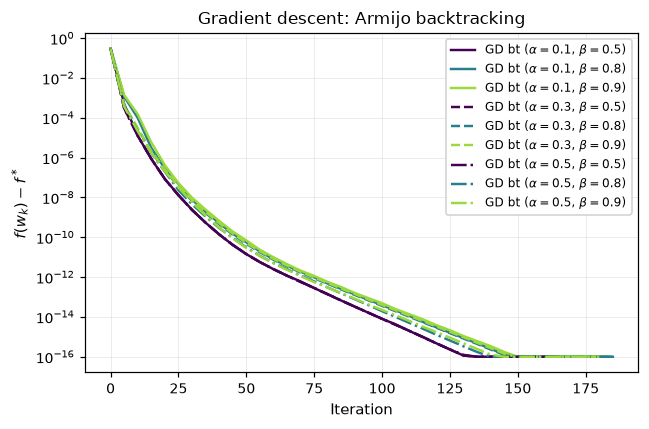

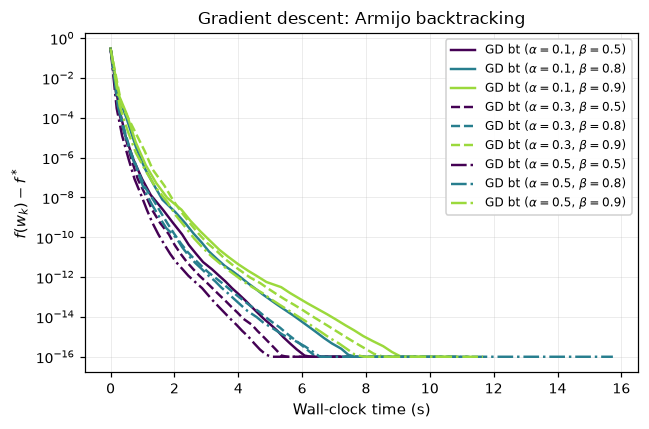

In [5]:
gd_bt = run_or_load(
    problem, "gd_backtracking", gd_backtracking_grid(problem), repeats=3, extra=config
)

# Nine curves on one panel: colour them by beta and dash them by alpha, so the
# figure shows directly which of the two parameters the spread belongs to.
plot_comparison(
    gd_bt,
    problem.f_star,
    stem="gd_backtracking",
    title="Gradient descent: Armijo backtracking",
    styles=styles_from_keys(
        [res.params["beta"] for res in gd_bt],
        [res.params["alpha"] for res in gd_bt],
    ),
)
plt.show()

### Chi phí của line search

Số lần đánh giá hàm mục tiêu trên mỗi vòng lặp phải được đo trong giai đoạn thuật
toán còn tiến triển. Khi hàm mục tiêu đã chạm giới hạn số học, điều kiện Armijo
không còn thỏa mãn được với bất kỳ độ dài bước nào, nên line search tiêu hết ngân
sách ở mọi vòng lặp và con số đo được bị thổi lên. Trên bài toán này giai đoạn
tiến triển kéo dài khoảng 115 vòng lặp, nên phép đo lấy trong 100 vòng đầu.

In [6]:
from src.runner import gd_backtracking_cost_grid

gd_bt_cost = run_or_load(
    problem, "gd_backtracking_cost", gd_backtracking_cost_grid(problem), repeats=1, extra=config
)

rows = []
for res in gd_bt_cost:
    evals = res.params.get("line_search_evals", 0)
    rows.append(
        {
            "setup": res.params["label"].replace("GD bt cost ", ""),
            "n_iter": res.n_iter,
            "line_search_evals": evals,
            "evals_per_iter": evals / max(res.n_iter, 1),
            "gap_at_stop": res.f_final - problem.f_star,
            "time_s": res.total_time,
        }
    )
pd.DataFrame(rows).sort_values("evals_per_iter")

[1/9] GD bt cost ($\alpha = 0.1$, $\beta = 0.5$)    status=max_iter   gap=8.035e-15 time=3.6519s


[2/9] GD bt cost ($\alpha = 0.1$, $\beta = 0.8$)    status=max_iter   gap=3.895e-14 time=4.4728s


[3/9] GD bt cost ($\alpha = 0.1$, $\beta = 0.9$)    status=max_iter   gap=4.874e-14 time=5.7750s


[4/9] GD bt cost ($\alpha = 0.3$, $\beta = 0.5$)    status=max_iter   gap=8.035e-15 time=4.0187s


[5/9] GD bt cost ($\alpha = 0.3$, $\beta = 0.8$)    status=max_iter   gap=3.595e-14 time=4.7491s


[6/9] GD bt cost ($\alpha = 0.3$, $\beta = 0.9$)    status=max_iter   gap=4.017e-14 time=5.5709s


[7/9] GD bt cost ($\alpha = 0.5$, $\beta = 0.5$)    status=max_iter   gap=8.039e-15 time=3.8219s


[8/9] GD bt cost ($\alpha = 0.5$, $\beta = 0.8$)    status=max_iter   gap=1.936e-14 time=4.4155s


[9/9] GD bt cost ($\alpha = 0.5$, $\beta = 0.9$)    status=max_iter   gap=2.246e-14 time=5.8170s
[done] gd_backtracking_cost: 9 runs written to gd_backtracking_cost.json


,setup,n_iter,line_search_evals,evals_per_iter,gap_at_stop,time_s
0,"($\alpha = 0.1$, $\beta = 0.5$)",100,139,1.39,8.035239e-15,3.651923
3,"($\alpha = 0.3$, $\beta = 0.5$)",100,139,1.39,8.035239e-15,4.018737
6,"($\alpha = 0.5$, $\beta = 0.5$)",100,139,1.39,8.038709e-15,3.821856
7,"($\alpha = 0.5$, $\beta = 0.8$)",100,237,2.37,1.936298e-14,4.415535
1,"($\alpha = 0.1$, $\beta = 0.8$)",100,246,2.46,3.895495e-14,4.472811
4,"($\alpha = 0.3$, $\beta = 0.8$)",100,247,2.47,3.595388e-14,4.749060
8,"($\alpha = 0.5$, $\beta = 0.9$)",100,396,3.96,2.245773e-14,5.817009
2,"($\alpha = 0.1$, $\beta = 0.9$)",100,412,4.12,4.873532e-14,5.775034
5,"($\alpha = 0.3$, $\beta = 0.9$)",100,415,4.15,4.016926e-14,5.570939


## C. SGD: ảnh hưởng của kích thước lô

[1/5] SGD ($B = 1$, $\eta = 1/L_B = 0.000322$)      status=max_iter   gap=1.015e-03 time=34.4684s


[2/5] SGD ($B = 16$, $\eta = 1/L_B = 0.00508$)      status=max_iter   gap=9.980e-04 time=4.2263s


[3/5] SGD ($B = 64$, $\eta = 1/L_B = 0.0195$)       status=max_iter   gap=9.575e-04 time=2.6626s


[4/5] SGD ($B = 256$, $\eta = 1/L_B = 0.0675$)      status=max_iter   gap=8.237e-04 time=1.8628s


[5/5] SGD ($B = 1024$, $\eta = 1/L_B = 0.175$)      status=max_iter   gap=1.157e-03 time=2.0353s
[done] sgd_batch: 5 runs written to sgd_batch.json


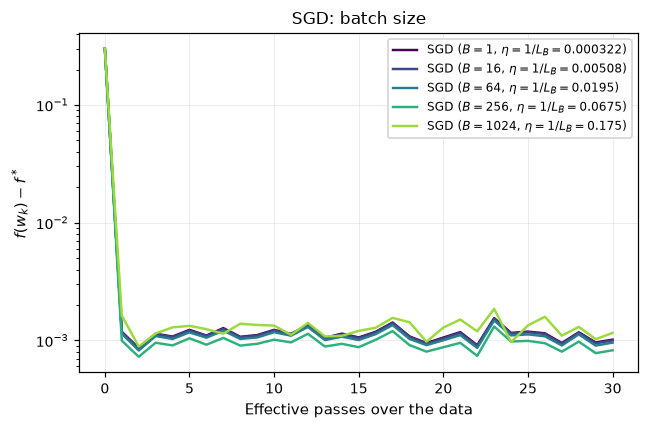

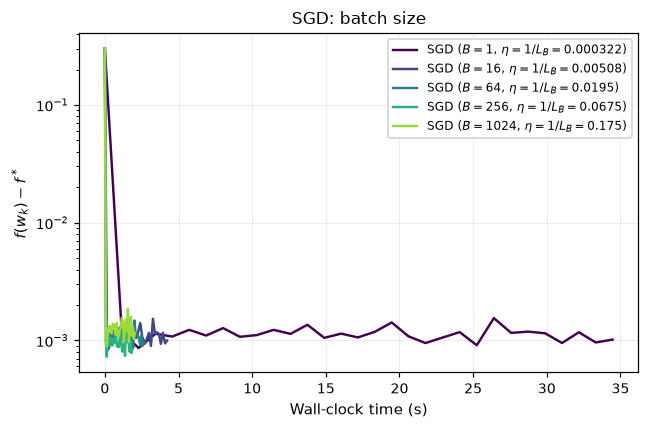

In [7]:
sgd_batch = run_or_load(
    problem, "sgd_batch", sgd_batch_size_grid(problem, epochs=30), repeats=3, extra=config
)

plot_comparison(
    sgd_batch,
    problem.f_star,
    stem="sgd_batch",
    title="SGD: batch size",
    first_axis="epoch",
    n_samples=problem.n,
)
plt.show()

Chú ý: trục hoành ở hình thứ nhất là số lượt duyệt dữ liệu, không phải số vòng
lặp, vì một vòng lặp SGD rẻ hơn nhiều một vòng lặp GD.

### Vì sao mỗi kích thước lô cần một độ dài bước riêng

Ngưỡng ổn định của một bước ngẫu nhiên do độ cong của các mẫu trong lô quyết định,
không phải do `L`. Với ma trận thiết kế rộng, hằng số Lipschitz của một mẫu đơn lẻ
lớn hơn `L` vài trăm lần. Thí nghiệm dưới dùng chung một độ dài bước `0.1/L` cho
mọi kích thước lô để thấy hệ quả.

L           = 2.6831
L_max_sample = 3109.7233   (tỉ lệ 1159.0 lần)
  B =    1: L_B = 3109.7233, 1/L_B = 3.216e-04
  B =   16: L_B =  196.8731, 1/L_B = 5.079e-03
  B =   64: L_B =   51.2306, 1/L_B = 1.952e-02
  B =  256: L_B =   14.8200, 1/L_B = 6.748e-02
  B = 1024: L_B =    5.7173, 1/L_B = 1.749e-01


[1/5] SGD ($B = 1$, common $\eta = 0.1/L = 0.0373$) status=diverged   gap=nan time=1.1566s


[2/5] SGD ($B = 16$, common $\eta = 0.1/L = 0.0373$) status=max_iter   gap=2.501e-02 time=4.3558s


[3/5] SGD ($B = 64$, common $\eta = 0.1/L = 0.0373$) status=max_iter   gap=2.164e-03 time=2.6354s


[4/5] SGD ($B = 256$, common $\eta = 0.1/L = 0.0373$) status=max_iter   gap=4.237e-04 time=1.9083s


[5/5] SGD ($B = 1024$, common $\eta = 0.1/L = 0.0373$) status=max_iter   gap=1.127e-04 time=2.0617s
[done] sgd_common_step: 5 runs written to sgd_common_step.json


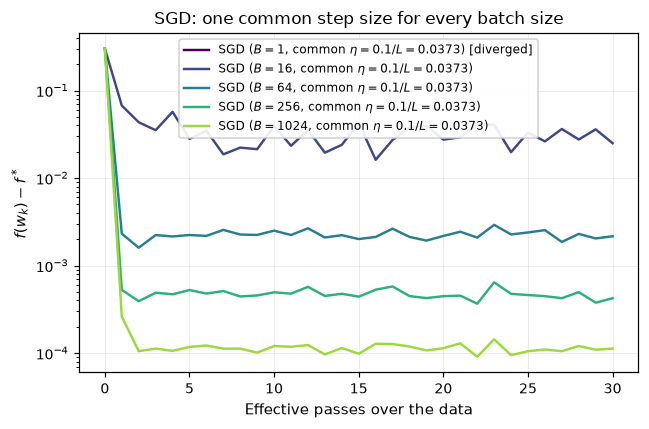

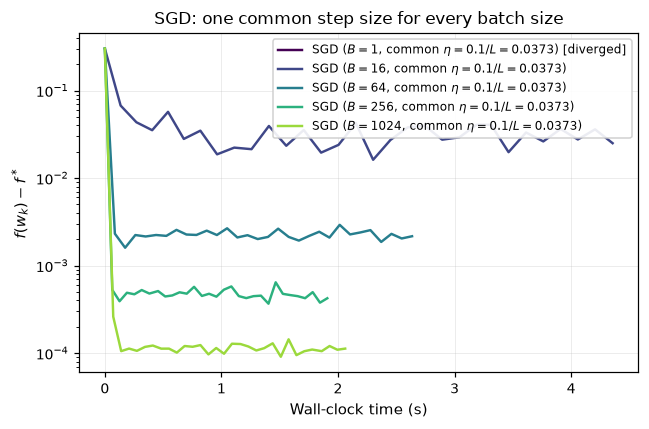

In [8]:
from src.runner import sgd_common_step_grid

print(f"L           = {problem.L:.4f}")
print(f"L_max_sample = {problem.L_max_sample:.4f}"
      f"   (tỉ lệ {problem.L_max_sample / problem.L:.1f} lần)")
for B in (1, 16, 64, 256, 1024):
    L_B = problem.minibatch_smoothness(B)
    print(f"  B = {B:>4}: L_B = {L_B:9.4f}, 1/L_B = {1 / L_B:.3e}")

sgd_common = run_or_load(
    problem, "sgd_common_step", sgd_common_step_grid(problem, epochs=30),
    repeats=3, extra=config
)

plot_comparison(
    sgd_common,
    problem.f_star,
    stem="sgd_common_step",
    title="SGD: one common step size for every batch size",
    first_axis="epoch",
    n_samples=problem.n,
)
plt.show()

## D. SGD: quy tắc chọn độ dài bước

[1/4] SGD ($B = 64$, $\eta_k = \eta_0$ constant)    status=max_iter   gap=9.575e-04 time=2.5920s


[2/4] SGD ($B = 64$, $\eta_k = \eta_0/(1 + 0.5k)$)  status=max_iter   gap=2.897e-05 time=2.6510s


[3/4] SGD ($B = 64$, $\eta_k = \eta_0/\sqrt{k+1}$)  status=max_iter   gap=1.462e-04 time=2.6378s


[4/4] SGD ($B = 64$, $\eta_k = \eta_0 \cdot 2^{-\lfloor k/5 \rfloor}$) status=max_iter   gap=5.797e-06 time=2.6063s
[done] sgd_schedule: 4 runs written to sgd_schedule.json


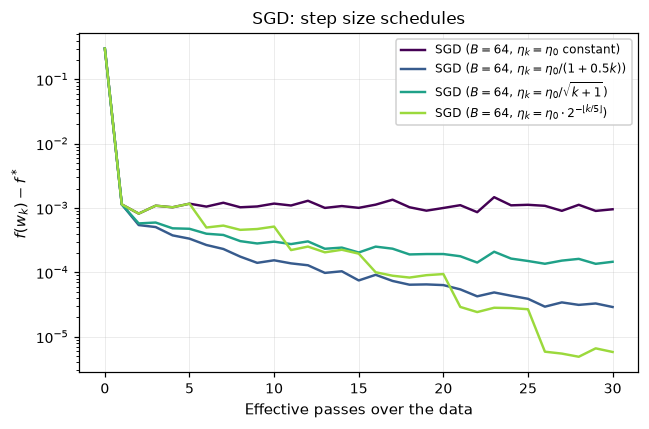

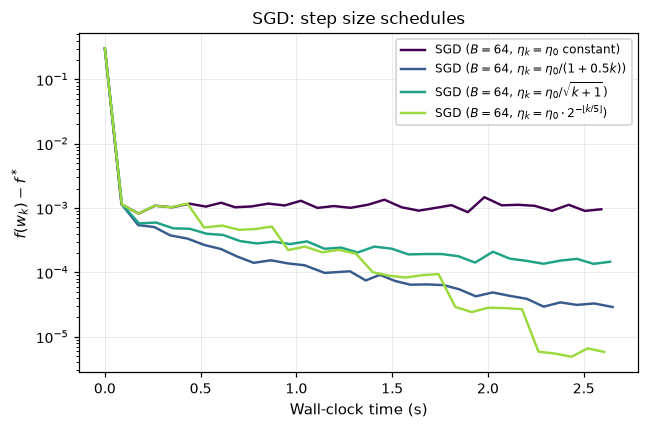

In [9]:
sgd_sched = run_or_load(
    problem, "sgd_schedule", sgd_schedule_grid(problem, epochs=30), repeats=3, extra=config
)

plot_comparison(
    sgd_sched,
    problem.f_star,
    stem="sgd_schedule",
    title="SGD: step size schedules",
    first_axis="epoch",
    n_samples=problem.n,
)
plt.show()

Với độ dài bước hằng, SGD không hội tụ về `w*` mà dừng lại trong một lân cận có
bán kính tỷ lệ với độ dài bước và phương sai gradient. Trên thang log, hiện tượng
này hiện ra thành đường nằm ngang.

## E. Accelerated gradient descent

[1/7] AGD ($\beta$ from $\kappa$)                   status=stalled    gap=0.000e+00 time=4.5179s


[2/7] AGD ($\beta$ from $\kappa$) + restart         status=stalled    gap=0.000e+00 time=4.5966s


[3/7] AGD ($\beta_k = (k-1)/(k+2)$)                 status=stalled    gap=1.735e-17 time=6.6721s


[4/7] AGD ($\beta_k = (k-1)/(k+2)$) + restart       status=converged  gap=-3.469e-18 time=2.9695s


[5/7] AGD ($\beta$ from $\kappa$, bt $\alpha = 0.5$, $t_0 = 1$) status=stalled    gap=0.000e+00 time=5.8966s


[6/7] AGD ($\beta$ from $\kappa$, bt $\alpha = 0.3$, $t_0 = 1/L$) status=stalled    gap=0.000e+00 time=6.2542s


[7/7] AGD ($\beta$ from $\kappa$, bt $\alpha = 0.3$, $t_0 = 1$) status=stalled    gap=5.508e-05 time=4.3746s
[done] agd: 7 runs written to agd.json


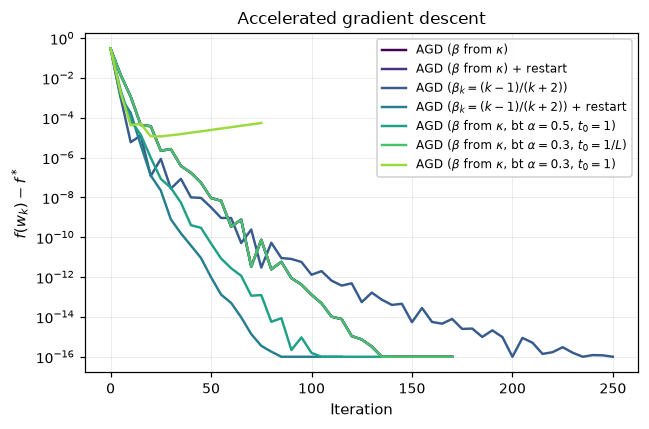

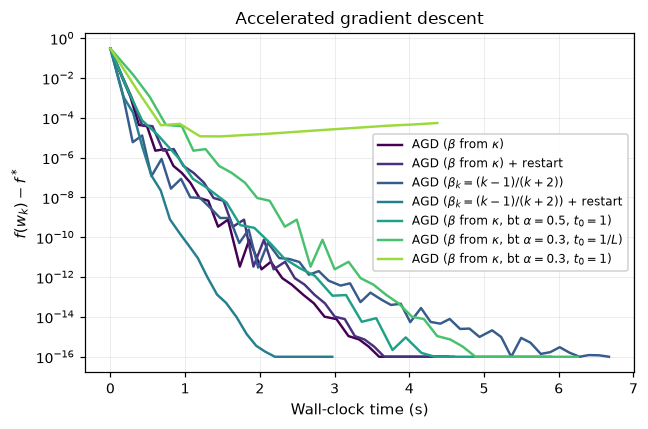

In [10]:
agd = run_or_load(problem, "agd", agd_grid(problem), repeats=3, extra=config)

plot_comparison(agd, problem.f_star, stem="agd", title="Accelerated gradient descent")
plt.show()

## Đối chiếu với tốc độ lý thuyết

hệ số co rút quan sát được:
  GD ($t = 2/L$)                           0.9999885937580808
  AGD ($\beta_k = (k-1)/(k+2)$) + restart  0.6545541695243703
cận GD  : 0.98520231
cận AGD : 0.93895043


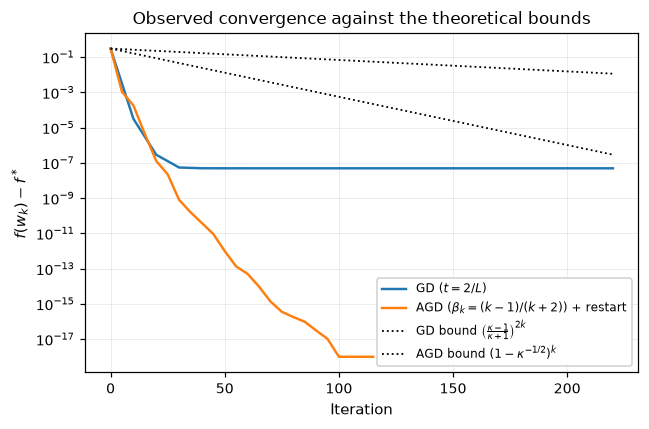

In [11]:
best_gd = best_result(gd_fixed, problem.f_star)
best_agd = best_result(agd, problem.f_star)

fig, ax = plt.subplots()
for res in (best_gd, best_agd):
    ax.semilogy(res.iter_hist, res.suboptimality(problem.f_star), label=res.params["label"])

gap0 = best_gd.f_hist[0] - problem.f_star
n_show = min(best_gd.n_iter, 1200)
plot_theoretical_rate(ax, gap0, problem.kappa, n_show, kind="gd")
plot_theoretical_rate(ax, gap0, problem.kappa, n_show, kind="agd")
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$f(w_k) - f^*$")
ax.set_title("Observed convergence against the theoretical bounds")
fig.tight_layout()

from src.plotting import save_figure
save_figure(fig, "theory_vs_practice")

print("hệ số co rút quan sát được:")
for res in (best_gd, best_agd):
    print(f"  {res.params['label']:<40s} {observed_rate(res, problem.f_star)}")
print(f"cận GD  : {((problem.kappa - 1) / (problem.kappa + 1)) ** 2:.8f}")
print(f"cận AGD : {1 - 1 / np.sqrt(problem.kappa):.8f}")